In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [110]:
basep = r'..\logs\data_20260709_'
endp = '.csv'
nump = ['143109', '143520', '151047', '175811', '182901']

comments = ['Leak Test No Valve', 'Leak Test Valve', 'Case 1', 'Case 2', 'Case 2 end']


In [111]:
dfs = [pd.read_csv(basep+nump[j]+endp, skiprows=1, usecols=[i for i in range(1,14)]) for j in range(5)]

In [112]:
dfs[0].columns

Index(['ts_ms', 'diaphragm_pct', 'piston_pct', 'TMP1075_temp_C', 'abp2_temp_C',
       'abp2_pressure_bar', 'abp2_ms_pressure_bar', 'MS5803_temp_C',
       'MS5803_pressure_bar', 'BMP280_temperature_C', 'BMP280_pressure_bar',
       'SHT45_temp_C', 'SHT45_humidity'],
      dtype='object')

In [113]:
n = 0
df = dfs[n]
title = comments[n]

n2 = 1
df2 = dfs[n2]
title = comments[n2]

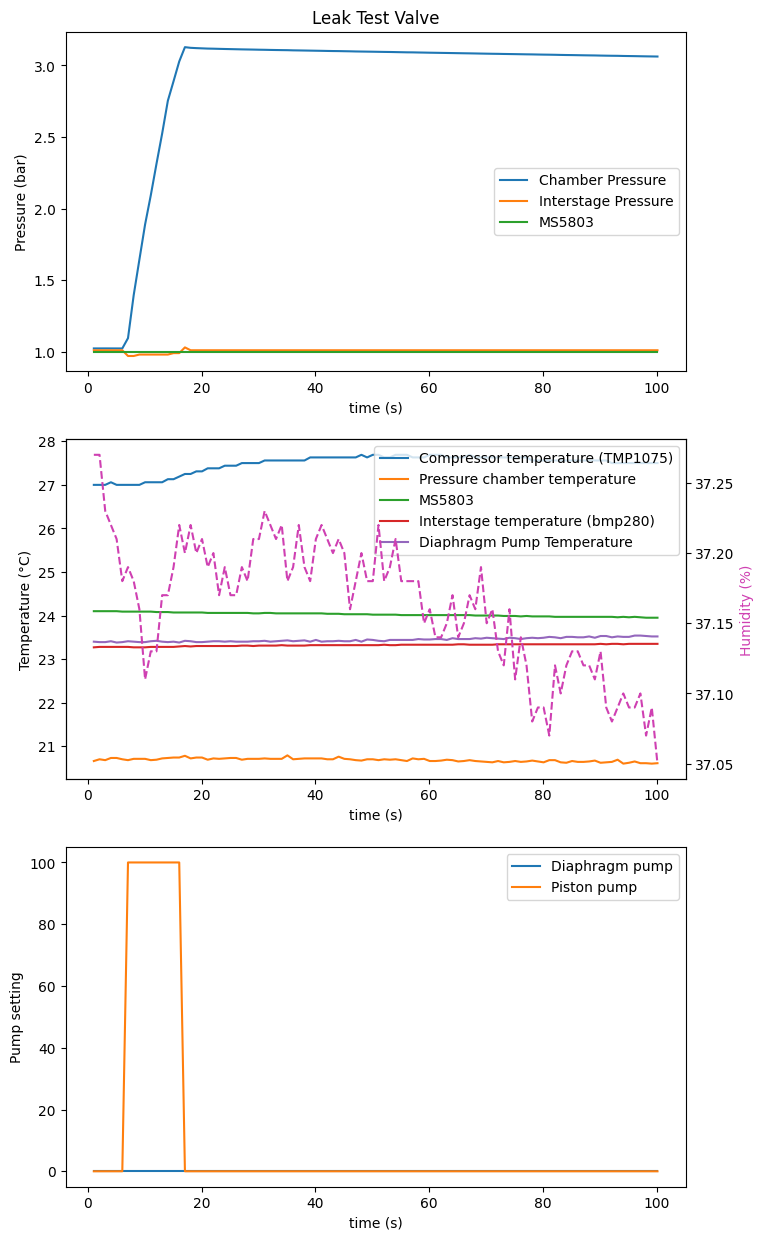

In [114]:
fig,axes = plt.subplots(3,1, figsize=(8,15))

axes[0].set_title(title)
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('Pressure (bar)')
#axes[0].plot(dfs[0].ts_ms/1000, dfs[0].abp2_pressure_bar, label='Chamber Pressure')
axes[0].plot(df.ts_ms/1000, df.abp2_ms_pressure_bar, label='Chamber Pressure')
axes[0].plot(df.ts_ms/1000, df.BMP280_pressure_bar, label='Interstage Pressure')
axes[0].plot(df.ts_ms/1000, df.MS5803_pressure_bar, label='MS5803')

axes[0].legend()
#axes[1].set_title('Only diaphragm pump with choked inlet')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].plot(df.ts_ms/1000, df.TMP1075_temp_C, label='Compressor temperature (TMP1075)')
axes[1].plot(df.ts_ms/1000, df.abp2_temp_C, label='Pressure chamber temperature')
axes[1].plot(df.ts_ms/1000, df.MS5803_temp_C, label='MS5803')
axes[1].plot(df.ts_ms/1000, df.BMP280_temperature_C, label='Interstage temperature (bmp280)')
axes[1].plot(df.ts_ms/1000, df.SHT45_temp_C, label='Diaphragm Pump Temperature')

axes[1].legend()

axrh = axes[1].twinx()
axrh.set_ylabel('Humidity (%)', color="#CF40B2")
axrh.plot(df.ts_ms/1000, df.SHT45_humidity, color="#CF40B2", linestyle = '--')


axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('Pump setting')
axes[2].plot(df.ts_ms/1000, df.diaphragm_pct, label='Diaphragm pump')
axes[2].plot(df.ts_ms/1000, df.piston_pct, label='Piston pump')
axes[2].legend()

In [115]:
V = 0.15*(0.1)**3 #l -> m^3
R_s = 287

In [116]:
tarr = np.array(df.ts_ms/1000)
p1arr = np.array(df.BMP280_pressure_bar) #pressure between the pumps
p2arr = np.array(df.abp2_ms_pressure_bar) #pressure in chamber
T1arr = np.array(df.BMP280_temperature_C) #interstage temperature
T2arr = np.array(df.abp2_temp_C) # chamber temperature

In [117]:
tarrn = np.zeros(tarr.shape[0]//5)
for i in range(tarr.shape[0]//5):
    tarrn[i] = tarr[i*5]

In [118]:
tarr2 = np.array(df2.ts_ms/1000)
p1arr2 = np.array(df2.BMP280_pressure_bar) #pressure between the pumps
p2arr2 = np.array(df2.abp2_ms_pressure_bar) #pressure in chamber
T1arr2 = np.array(df2.BMP280_temperature_C) #interstage temperature
T2arr2 = np.array(df2.abp2_temp_C) # chamber temperature

# Leak Test

In [119]:
fint = np.linspace(tarr2[0],tarr2[-1],100000)
finp=np.interp(fint, tarr2, p2arr2)

In [120]:
idx = np.where(finp==finp.max())[0][0]

In [121]:
dpdt2 = np.zeros(fint.shape[0]-idx)
for i, t in enumerate(fint[idx:]):
    dpdt2[i] = (finp[i]-finp[i-1])/(fint[i]-fint[i-1])

In [122]:
idx = np.where(p2arr==p2arr.max())[0][0]
idx2 = np.where(p2arr2==p2arr2.max())[0][0]

In [123]:
def dpdt_func(parr, tarr):
    dpdt = np.zeros(parr.shape[0]-1)
    for i, t in enumerate(tarr[:-1]):
        dpdt[i] = (parr[i]-parr[i+1])/(tarr[i]-tarr[i+1])
    return dpdt

In [124]:
dpdt = dpdt_func(p2arr[idx:], tarr[idx:])
dpdt2 = dpdt_func(p2arr2[idx2:], tarr2[idx2:])

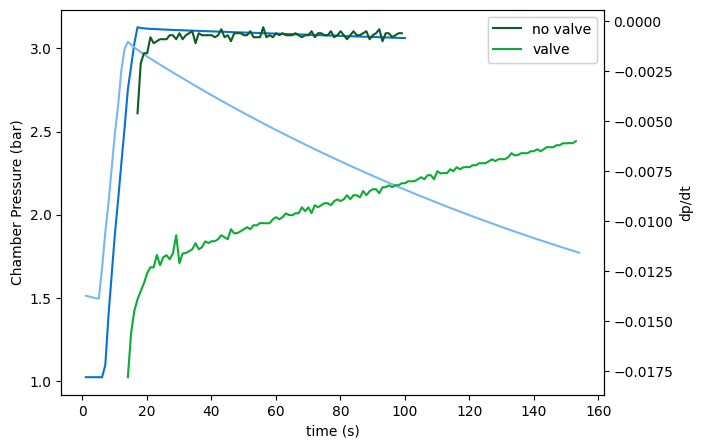

In [125]:
fig, axes = plt.subplots(1, figsize=(7,5))

axes.set_xlabel('time (s)')
axes.set_ylabel('Chamber Pressure (bar)')
axes.plot(tarr, p2arr, color="#0772D6", label='no valve')
axes.plot(tarr2, p2arr2, color="#77B7F3", label='valve')

axd = axes.twinx()

axd.set_ylabel('dp/dt')
axd.plot(tarr[idx:-1],dpdt, color="#0C5D20", label='no valve')
#axd.plot(fint[idx2:],dpdt2, color="#09CE3A", label='no valve')
axd.plot(tarr2[idx2:-1],dpdt2, color="#0AAC33", label='valve')

axd.legend()
axes.legend()


In [126]:
def Qs(dpdt, Tarr, parr):
    Qm = dpdt*1e5*V/(R_s*(Tarr+273.15))*6e4
    Qv = R_s*(Tarr+273.15)/(parr*1e5)*Qm
    return Qm, Qv

In [127]:
Qm_leak_novalve, Qv_leak_novalve = Qs(dpdt, T2arr[idx:-1], p2arr[idx:-1])

Qm2_leak_valve, Qv2_leak_valve = Qs(dpdt2, T2arr2[idx2:-1], p2arr2[idx2:-1])

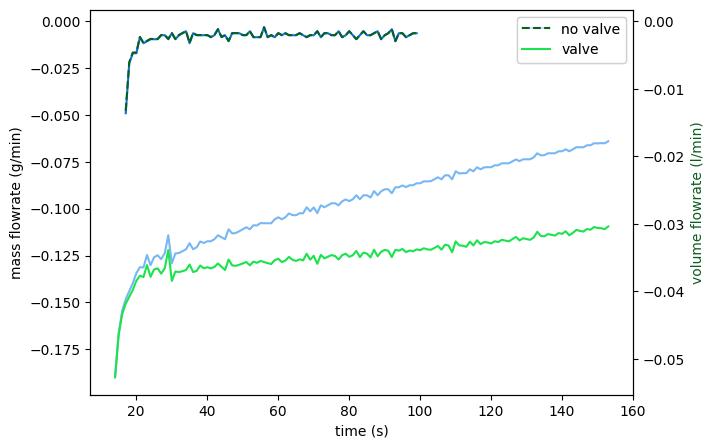

In [128]:
fig, axes = plt.subplots(1, figsize=(7,5))

#axes.set_ylim(-0.2,0.2)
axes.set_xlabel('time (s)')
axes.set_ylabel('mass flowrate (g/min)')
axes.plot(tarr[idx:-1], Qm_leak_novalve, color="#0772D6", label='no valve')
axes.plot(tarr2[idx2:-1], Qm2_leak_valve, color="#77B7F3", label='valve')
axes.legend()

axd = axes.twinx()

#axd.set_ylim(-0.06,0.05)
axd.set_ylabel('volume flowrate (l/min)', color="#0C5D20")
axd.plot(tarr[idx:-1],Qv_leak_novalve, linestyle='--', color="#0C5D20", label='no valve')
axd.plot(tarr2[idx2:-1],Qv2_leak_valve, color="#1CE24E", label='valve')
axd.legend()


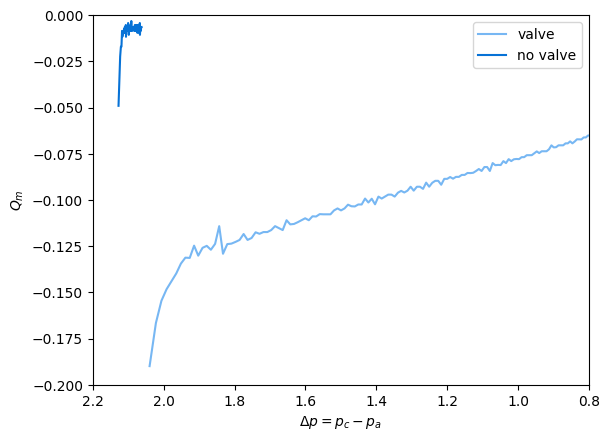

In [129]:
plt.xlabel(r'$\Delta p=p_c-p_a$')
plt.ylabel(r'$Q_m$')
plt.xlim(2.2,0.8)
plt.ylim(-0.2,0)
plt.plot(p2arr2[idx2:-1]-1, Qm2_leak_valve, color="#77B7F3",  label='valve')
plt.plot(p2arr[idx:-1]-1, Qm_leak_novalve, color="#0772D6", label='no valve')

plt.legend()

In [130]:
Qm_leak_novalve[10:].mean()
#Qm2_leak_valve[10:].mean()

-0.007295423512222763

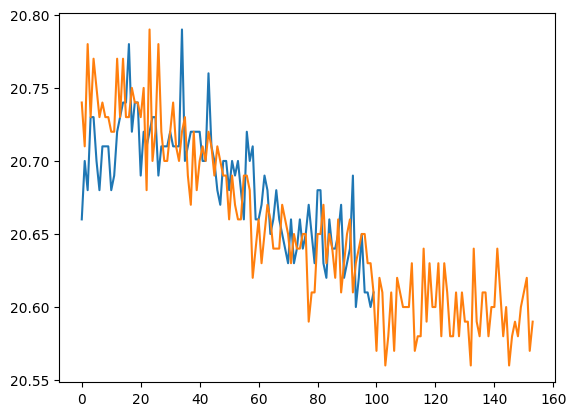

In [131]:
plt.plot(T2arr)
plt.plot(T2arr2)

# Case 1 - only Diaphragm pump

In [132]:
n = 2
df = dfs[n]
title = comments[n]


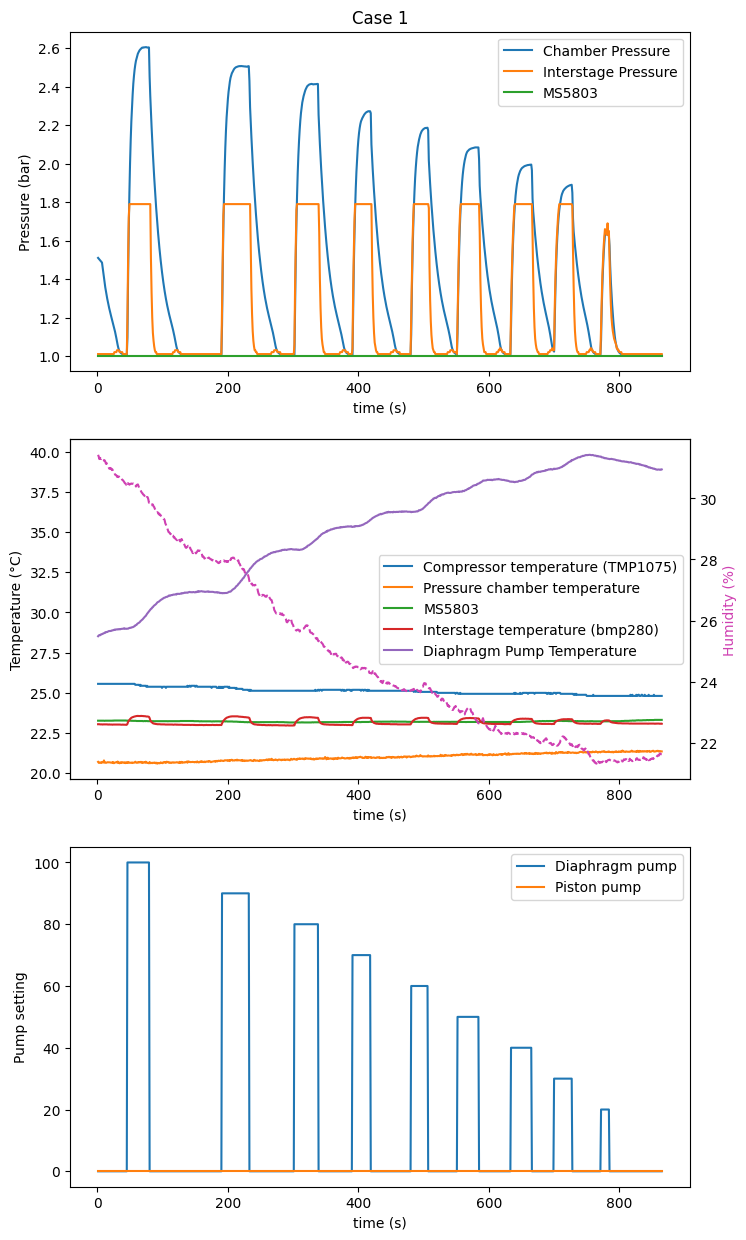

In [133]:
fig,axes = plt.subplots(3,1, figsize=(8,15))

axes[0].set_title(title)
axes[0].set_xlabel('time (s)')
axes[0].set_ylabel('Pressure (bar)')
#axes[0].plot(dfs[0].ts_ms/1000, dfs[0].abp2_pressure_bar, label='Chamber Pressure')
axes[0].plot(df.ts_ms/1000, df.abp2_ms_pressure_bar, label='Chamber Pressure')
axes[0].plot(df.ts_ms/1000, df.BMP280_pressure_bar, label='Interstage Pressure')
axes[0].plot(df.ts_ms/1000, df.MS5803_pressure_bar, label='MS5803')

axes[0].legend()
#axes[1].set_title('Only diaphragm pump with choked inlet')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].plot(df.ts_ms/1000, df.TMP1075_temp_C, label='Compressor temperature (TMP1075)')
axes[1].plot(df.ts_ms/1000, df.abp2_temp_C, label='Pressure chamber temperature')
axes[1].plot(df.ts_ms/1000, df.MS5803_temp_C, label='MS5803')
axes[1].plot(df.ts_ms/1000, df.BMP280_temperature_C, label='Interstage temperature (bmp280)')
axes[1].plot(df.ts_ms/1000, df.SHT45_temp_C, label='Diaphragm Pump Temperature')

axes[1].legend()

axrh = axes[1].twinx()
axrh.set_ylabel('Humidity (%)', color="#CF40B2")
axrh.plot(df.ts_ms/1000, df.SHT45_humidity, color="#CF40B2", linestyle = '--')


axes[2].set_xlabel('time (s)')
axes[2].set_ylabel('Pump setting')
axes[2].plot(df.ts_ms/1000, df.diaphragm_pct, label='Diaphragm pump')
axes[2].plot(df.ts_ms/1000, df.piston_pct, label='Piston pump')
axes[2].legend()

In [134]:
df.columns

Index(['ts_ms', 'diaphragm_pct', 'piston_pct', 'TMP1075_temp_C', 'abp2_temp_C',
       'abp2_pressure_bar', 'abp2_ms_pressure_bar', 'MS5803_temp_C',
       'MS5803_pressure_bar', 'BMP280_temperature_C', 'BMP280_pressure_bar',
       'SHT45_temp_C', 'SHT45_humidity'],
      dtype='object')

In [ ]:
p2_case1 = np.zeros((9, 70))
T2_case1 = np.zeros((9, 70))
Tpump_case1 = np.zeros((9, 70))
pwm_case1 = np.zeros(9)
t_case1 = np.zeros((9, 70))
idx0 = np.zeros(9, dtype=int)
idx2 = np.zeros(9, dtype=int)

for i in range(2,11):
    part = df.loc[df.diaphragm_pct==i*10]
    p = np.array(part.abp2_ms_pressure_bar)
    T = np.array(part.abp2_temp_C)
    Tp = np.array(part.SHT45_temp_C)
    t = np.array(part.ts_ms)/1000
    pwm_case1[i-2] = i*10 
    idx0[i-2] = int(np.shape(t)[0])
    idx2[i-2] = part.index[-1]

    for j in range(t.shape[0]):
        p2_case1[i-2,j] = p[j]
        T2_case1[i-2,j] = T[j]
        Tpump_case1[i-2,j] = Tp[j]
        t_case1[i-2,j] = t[j]

array([ 20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.])

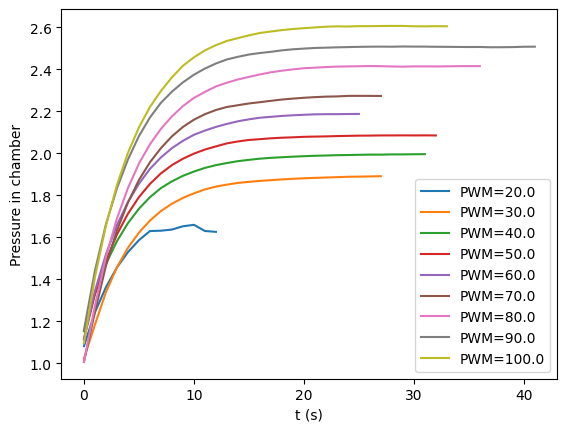

In [138]:
plt.xlabel('t (s)')
plt.ylabel('Pressure in chamber')
for i in range(9):
    plt.plot(t_case1[i,:idx0[i]]-t_case1[i,0], p2_case1[i, :idx0[i]], label=f'PWM={pwm_case1[i]}')
    plt.legend()

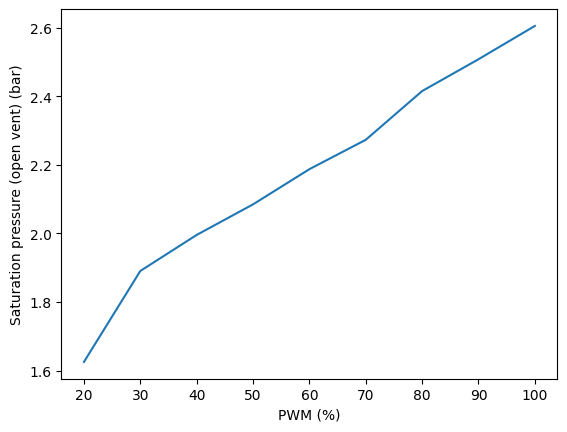

In [139]:
plt.ylabel('Saturation pressure (open vent) (bar)')
plt.xlabel('PWM (%)')
plt.plot(pwm_case1, [p2_case1[i, idx0[i]-1] for i in range(9)])

In [140]:
dpdtarr = np.zeros((9,70))
for i in range(9):
    dpdt = dpdt_func(p2_case1[i,:idx0[i]], t_case1[i,:idx0[i]])
    for j in range(idx0[i]-1):
        dpdtarr[i,j] = dpdt[j]

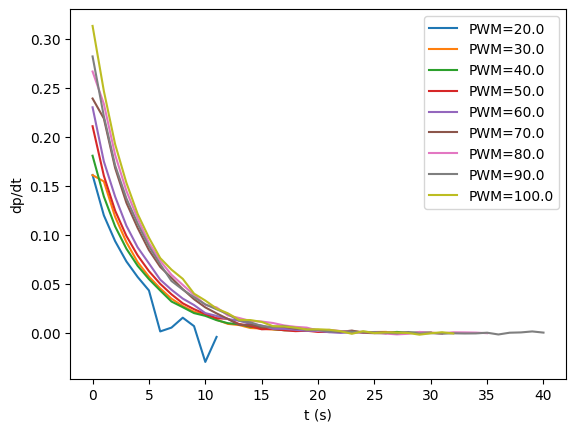

In [141]:
plt.xlabel('t (s)')
plt.ylabel('dp/dt')
for i in range(9):
    plt.plot(t_case1[i,:idx0[i]-1]-t_case1[i,0], dpdtarr[i, :idx0[i]-1], label=f'PWM={pwm_case1[i]}')
    plt.legend()

In [142]:
Qmarr = np.zeros((9,70))
Qvarr = np.zeros((9,70))
for i in range(9):
    Qm, Qv = Qs(dpdtarr[i, :idx0[i]-1],T2_case1[i,:idx0[i]-1], p2_case1[i, :idx0[i]-1])
    for j in range(idx0[i]-1):
        Qmarr[i,j] = Qm[j]
        Qvarr[i,j] = Qv[j]

    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


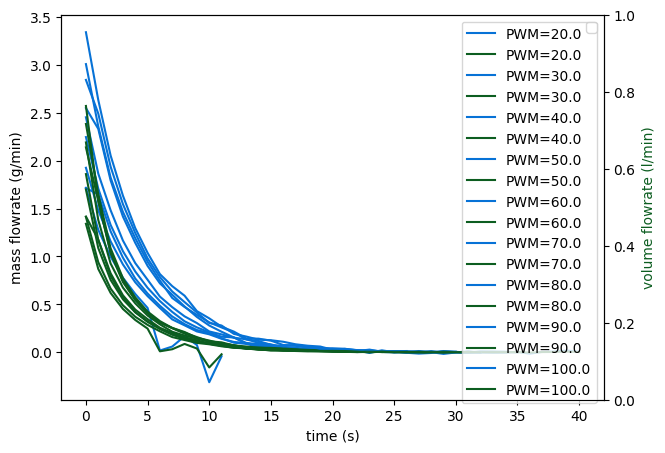

In [143]:
fig, axes = plt.subplots(1, figsize=(7,5))

#axes.set_ylim(-0.2,0.2)
axes.set_xlabel('time (s)')
axes.set_ylabel('mass flowrate (g/min)')
axd = axes.twinx()
axd.set_ylabel('volume flowrate (l/min)', color="#0C5D20")

for i in range(9):
    axes.plot(t_case1[i,:idx0[i]-1]-t_case1[i,0], Qmarr[i,:idx0[i]-1], color="#0772D6", label=f'PWM={pwm_case1[i]}')
    axes.plot(t_case1[i,:idx0[i]-1]-t_case1[i,0], Qvarr[i,:idx0[i]-1], color="#0C5D20", label=f'PWM={pwm_case1[i]}')



axes.legend()
axd.legend()

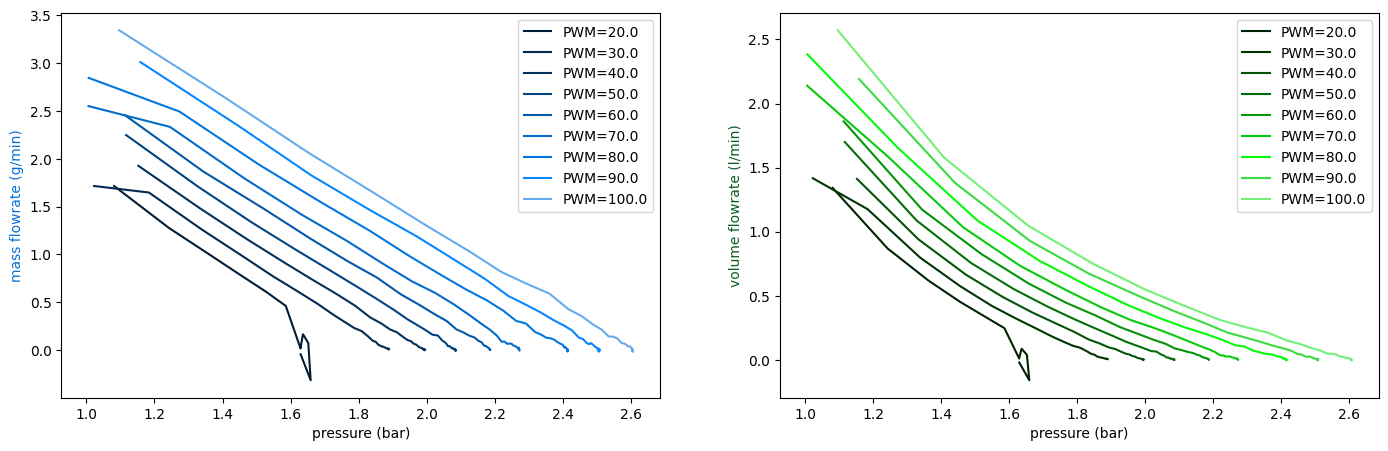

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(17,5))

#axes.set_ylim(-0.2,0.2)
axes[0].set_xlabel('pressure (bar)')
axes[0].set_ylabel('mass flowrate (g/min)',color="#0772D6")
#axd = axes.twinx()
axes[1].set_xlabel('pressure (bar)')
axes[1].set_ylabel('volume flowrate (l/min)', color="#0C5D20")

blues = ["#011C35", "#022A50", "#03305A", "#024481", "#0358A7", "#046BCB", "#0476E0", "#0787FF", "#66ABEB"]
greens = ["#012202", "#023304", "#035406", "#056E09", "#059309", "#06CA0D", "#03FA0B", "#3ADB3F", "#72F077"]

for i in range(9):
    axes[0].plot(p2_case1[i,:idx0[i]-1], Qmarr[i,:idx0[i]-1], color=blues[i], label=f'PWM={pwm_case1[i]}')
    axes[1].plot(p2_case1[i,:idx0[i]-1], Qvarr[i,:idx0[i]-1], color=greens[i], label=f'PWM={pwm_case1[i]}')



axes[0].legend()
axes[1].legend()

In [162]:
p2_case1_post = np.zeros((9, 40))
T2_case1_post = np.zeros((9, 40))
Tpump_case1_post = np.zeros((9, 40))
pwm_case1_post = np.zeros(9)
t_case1_post = np.zeros((9, 40))

for i in range(9):
    part = df.iloc[idx2[i]:idx2[i]+40]
    p = np.array(part.abp2_ms_pressure_bar)
    T = np.array(part.abp2_temp_C)
    Tp = np.array(part.SHT45_temp_C)
    t = np.array(part.ts_ms)/1000
    pwm_case1_post[i] = (i+2)*10 

    for j in range(t.shape[0]):
        p2_case1_post[i,j] = p[j]
        T2_case1_post[i,j] = T[j]
        Tpump_case1_post[i,j] = Tp[j]
        t_case1_post[i,j] = t[j]


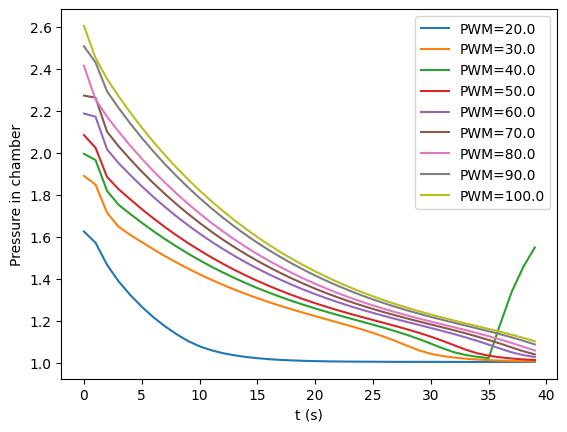

In [163]:
plt.xlabel('t (s)')
plt.ylabel('Pressure in chamber')
for i in range(9):
    plt.plot(t_case1_post[i]-t_case1_post[i,0], p2_case1_post[i], label=f'PWM={pwm_case1[i]}')
    plt.legend()

In [171]:
dpdtarr_post = np.zeros((9,39))
for i in range(9):
    dpdt = dpdt_func(p2_case1_post[i], t_case1_post[i])
    for j in range(np.shape(dpdt)[0]):
        dpdtarr_post[i,j] = dpdt[j]

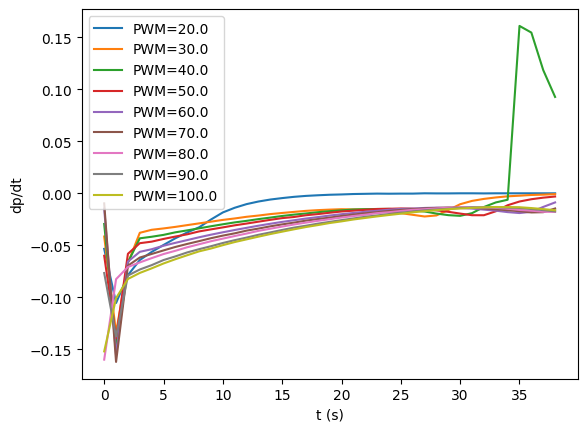

In [172]:
plt.xlabel('t (s)')
plt.ylabel('dp/dt')
for i in range(9):
    plt.plot(t_case1_post[i,:-1]-t_case1_post[i,0], dpdtarr_post[i], label=f'PWM={pwm_case1[i]}')
    plt.legend()

In [178]:
Qmarrout = np.zeros((9,39))
Qvarrout = np.zeros((9,39))
for i in range(9):
    Qm, Qv = Qs(dpdtarr_post[i],T2_case1_post[i,:-1], p2_case1_post[i,:-1])
    for j in range(np.shape(Qm)[0]):
        Qmarrout[i,j] = Qm[j]
        Qvarrout[i,j] = Qv[j]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


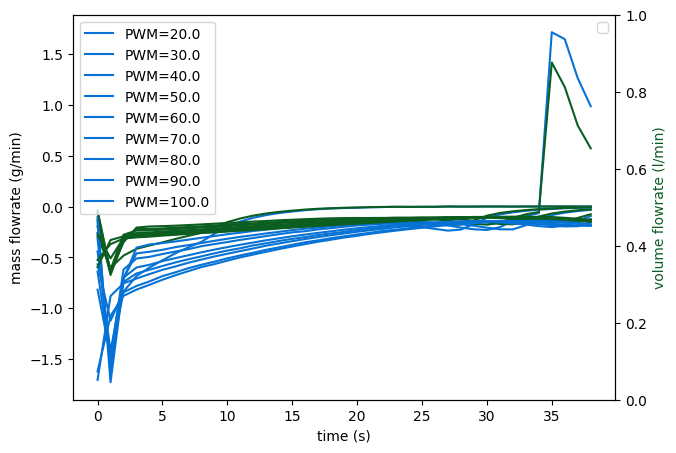

In [181]:
fig, axes = plt.subplots(1, figsize=(7,5))

#axes.set_ylim(-0.2,0.2)
axes.set_xlabel('time (s)')
axes.set_ylabel('mass flowrate (g/min)')
axd = axes.twinx()
axd.set_ylabel('volume flowrate (l/min)', color="#0C5D20")

for i in range(9):
    axes.plot(t_case1_post[i,:-1]-t_case1_post[i,0], Qmarrout[i], color="#0772D6", label=f'PWM={pwm_case1[i]}')
    axes.plot(t_case1_post[i,:-1]-t_case1_post[i,0], Qvarrout[i], color="#0C5D20")#, label=f'PWM={pwm_case1[i]}')



axes.legend()
axd.legend()

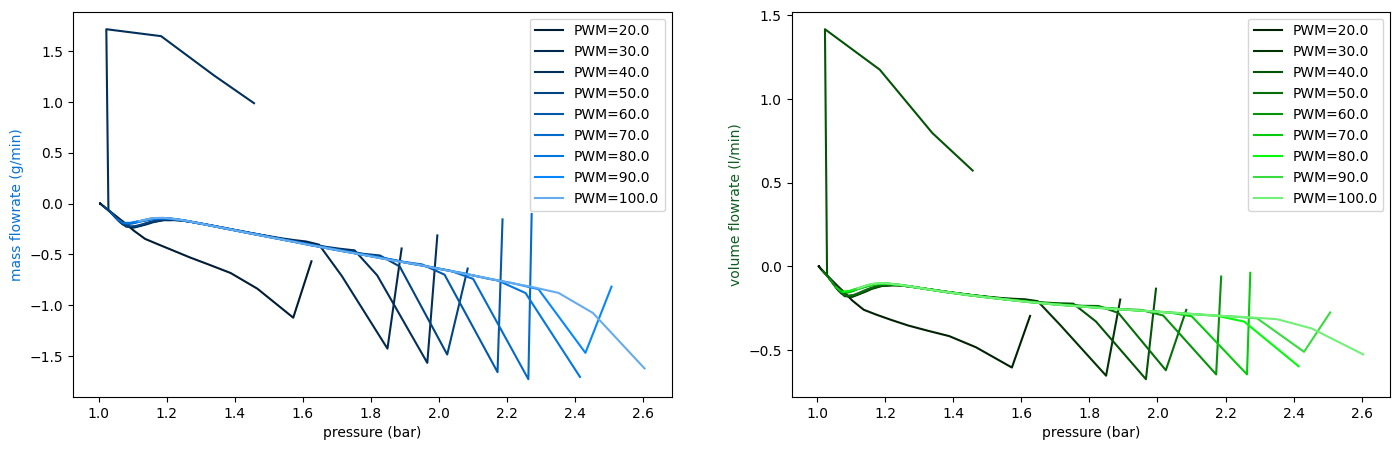

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(17,5))

#axes.set_ylim(-0.2,0.2)
axes[0].set_xlabel('pressure (bar)')
axes[0].set_ylabel('mass flowrate (g/min)',color="#0772D6")
#axd = axes.twinx()
axes[1].set_xlabel('pressure (bar)')
axes[1].set_ylabel('volume flowrate (l/min)', color="#0C5D20")

blues = ["#011C35", "#022A50", "#03305A", "#024481", "#0358A7", "#046BCB", "#0476E0", "#0787FF", "#66ABEB"]
greens = ["#012202", "#023304", "#035406", "#056E09", "#059309", "#06CA0D", "#03FA0B", "#3ADB3F", "#72F077"]

for i in range(9):
    axes[0].plot(p2_case1_post[i,:-1], Qmarrout[i], color=blues[i], label=f'PWM={pwm_case1[i]}')
    axes[1].plot(p2_case1_post[i,:-1], Qvarrout[i], color=greens[i], label=f'PWM={pwm_case1[i]}')



axes[0].legend()
axes[1].legend()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(17,5))

#axes.set_ylim(-0.2,0.2)
axes[0].set_xlabel('pressure (bar)')
axes[0].set_ylabel('mass flowrate (g/min)',color="#0772D6")
#axd = axes.twinx()
axes[1].set_xlabel('pressure (bar)')
axes[1].set_ylabel('volume flowrate (l/min)', color="#0C5D20")

blues = ["#011C35", "#022A50", "#03305A", "#024481", "#0358A7", "#046BCB", "#0476E0", "#0787FF", "#66ABEB"]
greens = ["#012202", "#023304", "#035406", "#056E09", "#059309", "#06CA0D", "#03FA0B", "#3ADB3F", "#72F077"]

for i in range(9):
    axes[0].plot(p2_case1_post[i,:-1], Qmarrout[i], color=blues[i], label=f'PWM={pwm_case1[i]}')
    axes[1].plot(p2_case1_post[i,:-1], Qvarrout[i], color=greens[i], label=f'PWM={pwm_case1[i]}')



axes[0].legend()
axes[1].legend()